In [1]:
from pathlib import Path
import sys, os

scriptPath = Path.cwd()
parentPath = scriptPath.parent
dataPath = parentPath / 'data'
srcPath = parentPath / 'src'
modelPath = parentPath / 'models'
savePath = parentPath / 'results'
plotPath = parentPath / 'plots'

sys.path.append(srcPath.as_posix())

## Load the data

In [2]:
import numpy as np
import torch

data = np.load(dataPath / 'barcode1010_l10_4k1k.npz')

X = torch.from_numpy(data['X'])
y = torch.from_numpy(data['y'])
X.shape, y.shape


(torch.Size([5000, 10]), torch.Size([5000]))

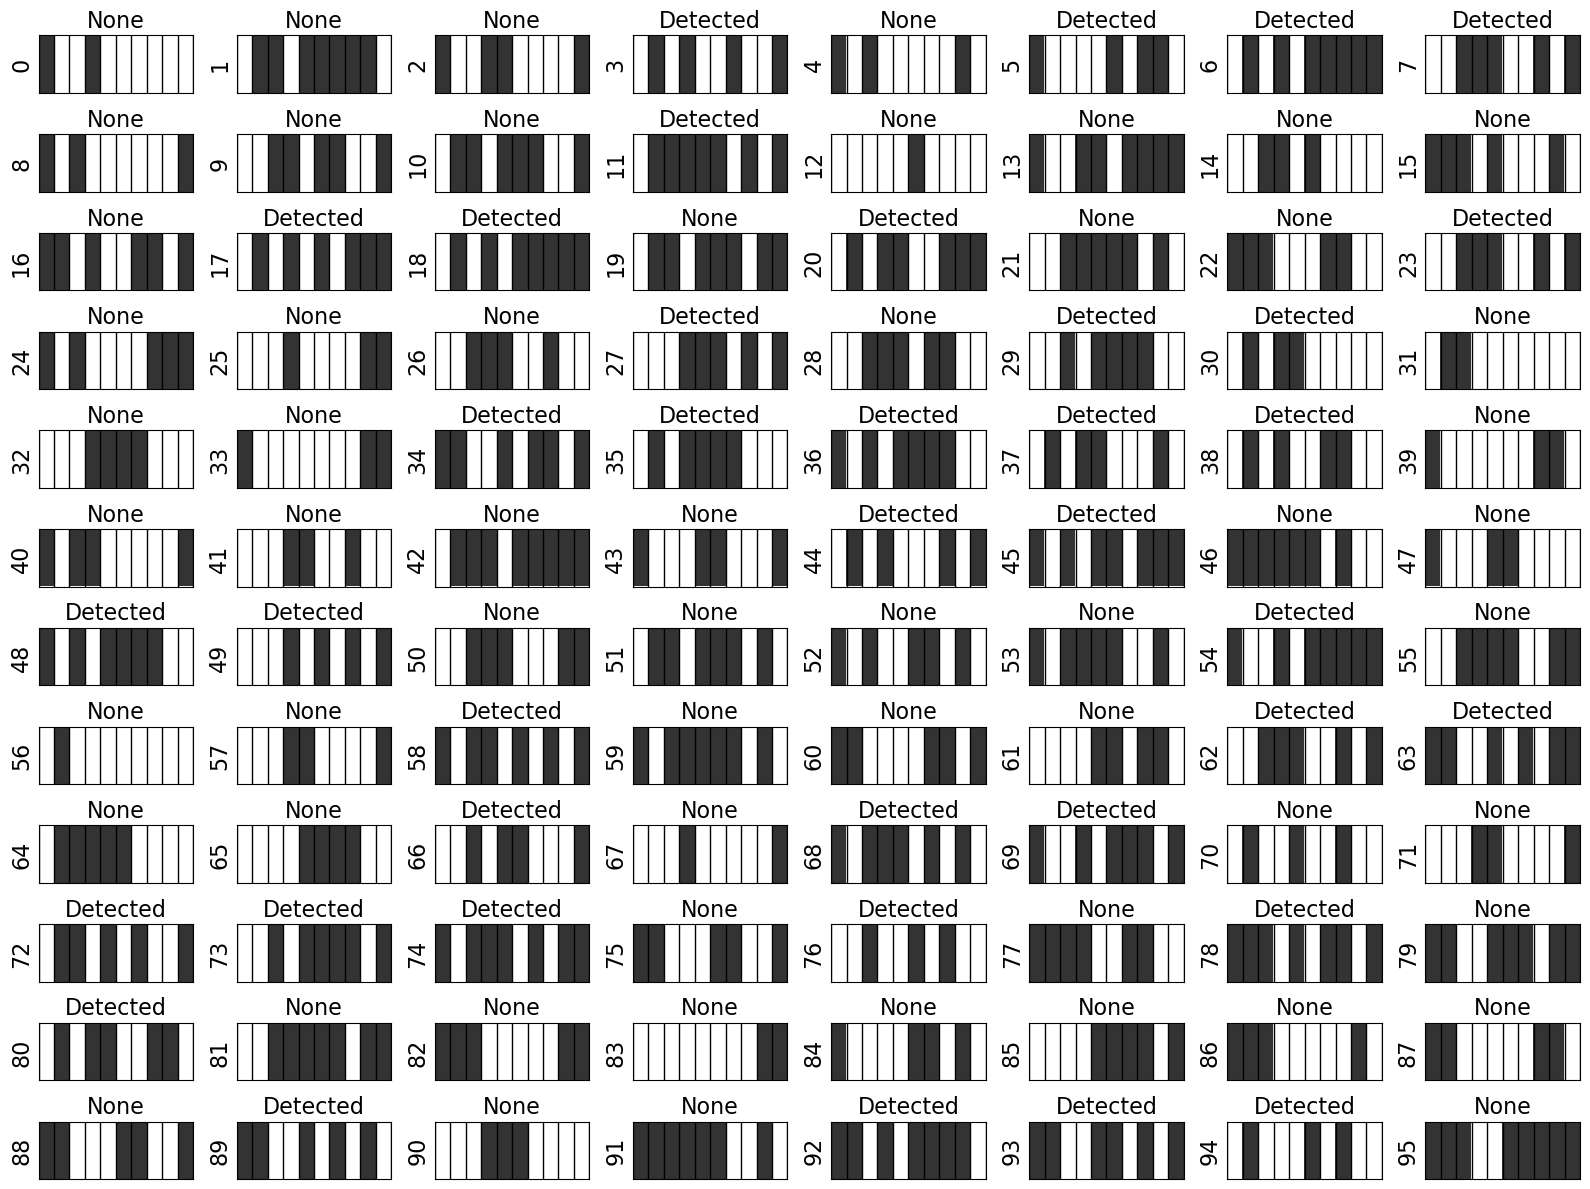

In [3]:
import matplotlib.pyplot as plt

nx, ny = 12,8
fig, axs = plt.subplots(nx, ny, figsize=(ny*2, nx))
namestr = ['None', 'Detected']
for i in range(nx):
    for j in range(ny):
        ax = axs[i, j]
        ind = i * ny + j
        if ind < X.shape[0]:
            ax.imshow(X[ind].unsqueeze(0), vmin=-0.25, vmax=1.,cmap='binary_r',aspect='auto')
            
            # Add vertical lines
            for ii in range(X[ind].shape[0] + 1):
                ax.axvline(ii - 0.5, color='black', linewidth=1)
            
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_ylabel(ind,fontsize=16)
            ax.set_title(namestr[int(y[ind].item())],fontsize=16)
            # ax.set_axis_off()
plt.tight_layout()

In [4]:
from torch.utils.data import TensorDataset, DataLoader

input_size = 10
num_classes = 2

n_samples = X.shape[0]
train_size = int(0.8 * n_samples)
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size].type(torch.long), y[train_size:].type(torch.long)

test_dataset = TensorDataset(X_val, y_val)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

## Load the models

In [5]:
from PANS_linear import PANS_active

device = 'cpu'
thePath = modelPath / 'barcode1010'

models = {}
dfs = []
for f in os.listdir(thePath):
    if f.startswith(f'bc1010l10_4k1k_N'):
        N = int(f.split('_')[2][1:].split('.')[0])
        dfs.append(N)
        print(N,f)

        n_chans = []
        n_kers = 0
        pool_size = 2      
        fc_config = [512]
        pool_type = 'avg'
        if_logsoft = True

        model = PANS_active(n_input=input_size, n_output=num_classes, n_feature=N, pool_type=pool_type, conv_channels=n_chans, conv_kernel=n_kers, pool_size=pool_size, fc_units=fc_config, use_feature_batchnorm=True,use_logsoft=if_logsoft).to(device)

        model.load_state_dict(torch.load(thePath / f, map_location=device))
        model.to(device)
        model.eval()
        models[N] = model

dfs.sort()
dfs

8 bc1010l10_4k1k_N8.pth
3 bc1010l10_4k1k_N3.pth
4 bc1010l10_4k1k_N4.pth
6 bc1010l10_4k1k_N6.pth
10 bc1010l10_4k1k_N10.pth
12 bc1010l10_4k1k_N12.pth


[3, 4, 6, 8, 10, 12]

## Simulation results

In [6]:
import pandas as pd

n_T = 100
temp_results = []

for dcr in [0,0.01,0.03]:
    print('\nDark Count Rate:\t',dcr)

    for df in dfs:
        model = models[df]

        photon_count = 0
        acc_arr = np.zeros((n_T))
        for data, target in test_loader:
            data = data.to(device).reshape(data.shape[0],-1)
            target = target.to(device)
            
            photon_count += model.get_acts(data).sum().item()+df*dcr*data.shape[0]

            for j in range(n_T):
                output = model.robust_test(data,dcr=dcr,n_rep=1)
                pred = output.data.max(1, keepdim=True)[1] # get the index of the max log-probability
                correct = pred.eq(target.data.view_as(pred)).cpu().sum()
                acc_arr[j] += correct
            # break

        acc_arr = acc_arr / float(len(test_dataset))
        photon_count = photon_count / float(len(test_dataset))
        mean_acc = 100. * acc_arr.mean()
        std_dev = 100. * acc_arr.std()

        # append the results to DataFrame
        temp_results.append({'d_f': df, 'dcr':dcr, 'mean_accuracy': mean_acc, 'std_dev': std_dev, 'det_photon_count': photon_count})

        print(f"Photon count {photon_count:.4g} \t{np.round(mean_acc,2):.2f} ± {np.round(std_dev,2):.2f}% (dcr {dcr}, repeat {n_T})")

results_df = pd.concat([pd.DataFrame([i]) for i in temp_results], ignore_index=True)



Dark Count Rate:	 0
Photon count 2.148 	69.40 ± 0.57% (dcr 0, repeat 100)
Photon count 2.832 	71.34 ± 0.78% (dcr 0, repeat 100)
Photon count 3.541 	75.73 ± 0.74% (dcr 0, repeat 100)
Photon count 4.399 	85.12 ± 0.51% (dcr 0, repeat 100)
Photon count 5.245 	99.55 ± 0.20% (dcr 0, repeat 100)
Photon count 6.81 	99.94 ± 0.07% (dcr 0, repeat 100)

Dark Count Rate:	 0.01
Photon count 2.188 	69.16 ± 0.62% (dcr 0.01, repeat 100)
Photon count 2.858 	71.12 ± 0.79% (dcr 0.01, repeat 100)
Photon count 3.619 	75.55 ± 0.80% (dcr 0.01, repeat 100)
Photon count 4.464 	84.54 ± 0.54% (dcr 0.01, repeat 100)
Photon count 5.343 	98.48 ± 0.35% (dcr 0.01, repeat 100)
Photon count 6.932 	98.84 ± 0.36% (dcr 0.01, repeat 100)

Dark Count Rate:	 0.03
Photon count 2.258 	69.05 ± 0.76% (dcr 0.03, repeat 100)
Photon count 2.923 	71.00 ± 0.84% (dcr 0.03, repeat 100)
Photon count 3.711 	74.99 ± 0.87% (dcr 0.03, repeat 100)
Photon count 4.638 	83.19 ± 0.77% (dcr 0.03, repeat 100)
Photon count 5.543 	96.44 ± 0.50% (dcr

In [7]:
results_df.to_pickle(savePath / 'barcode1010_active_sim.npy')
results_df

,d_f,dcr,mean_accuracy,std_dev,det_photon_count
0,3,0.00,69.396,0.573571,2.148
1,4,0.00,71.336,0.778141,2.832
2,6,0.00,75.732,0.739443,3.541
3,8,0.00,85.125,0.507223,4.399
4,10,0.00,99.555,0.196150,5.245
5,12,0.00,99.935,0.071239,6.810
6,3,0.01,69.160,0.615630,2.188
7,4,0.01,71.124,0.787289,2.858
8,6,0.01,75.554,0.802175,3.619
9,8,0.01,84.539,0.542198,4.464


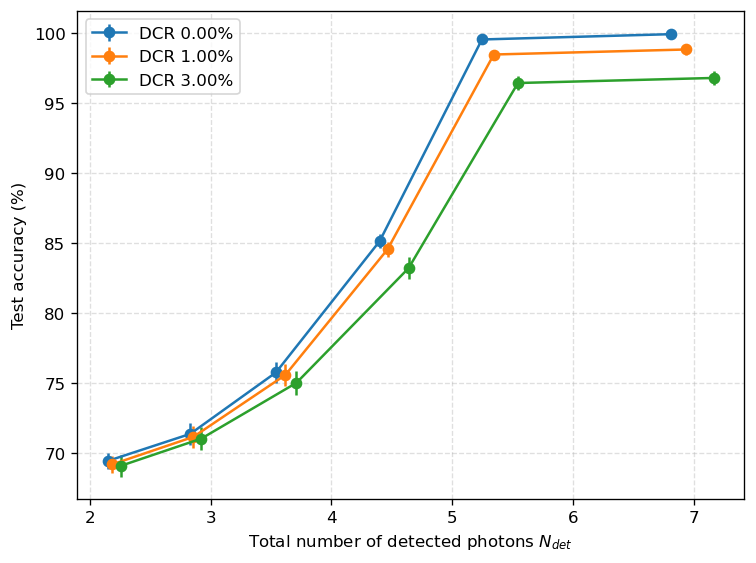

In [8]:
import matplotlib.pyplot as plt

k_val = 1

fig, ax = plt.subplots(dpi=120)

for dcr in results_df['dcr'].unique():
    the_df = results_df[results_df['dcr'] == dcr].sort_values('d_f')
    plt.errorbar(the_df['det_photon_count'],the_df['mean_accuracy'],yerr=the_df['std_dev'],fmt='-o',label=f'DCR {dcr*100:.2f}%')

plt.xlabel(r'Total number of detected photons $N_{det}$')
plt.ylabel('Test accuracy (%)')

ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()